In [2]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  
from matplotlib.ticker import FuncFormatter

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [10]:
df_plot = df['job_title_short'].value_counts().to_frame()
df_plot

,count
job_title_short,
Data Analyst,196075
Data Engineer,186241
Data Scientist,172286
Business Analyst,49063
Software Engineer,44929
Senior Data Engineer,44563
Senior Data Scientist,36957
Senior Data Analyst,29216
Machine Learning Engineer,14080


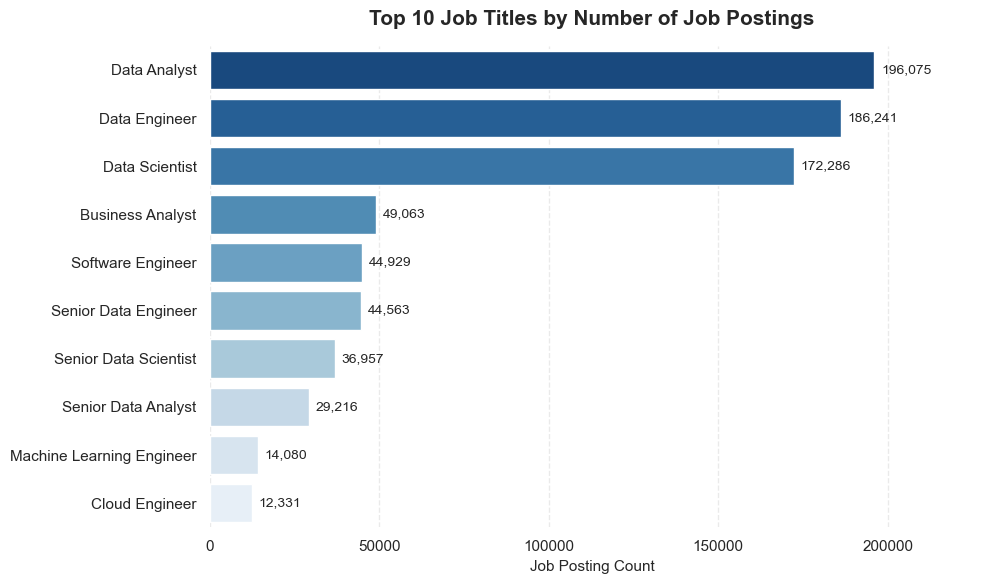

In [16]:
# Prepare only for plotting
plot_data = df_plot.sort_values('count', ascending=False).head(10).reset_index()
plot_data.columns = ['job_title', 'count']

# Style
sns.set_theme(style='whitegrid')

plt.figure(figsize=(10, 6))

# Dark = highest count, light = lowest count
colors = sns.color_palette('Blues_r', n_colors=len(plot_data))

ax = sns.barplot(
    data=plot_data,
    x='count',
    y='job_title',
    hue='job_title',
    palette=colors,
    legend=False
)

# Title and labels
ax.set_title(
    'Top 10 Job Titles by Number of Job Postings',
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Job Posting Count', fontsize=11)
ax.set_ylabel('')

# Add value labels
offset = plot_data['count'].max() * 0.01

for i, value in enumerate(plot_data['count']):
    ax.text(
        value + offset,
        i,
        f'{value:,}',
        va='center',
        fontsize=10
    )

# Clean look
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.grid(axis='y', visible=False)

plt.xlim(0, plot_data['count'].max() * 1.15)
sns.despine(left=True, bottom=True)
plt.tight_layout()



plt.savefig("top_10_job_titles_by_count.png", dpi=300, bbox_inches="tight")

plt.show()